In [1]:
#this is a generic code for looking at the continous HOBO data against the manual field measurements for one Bell Field Piezometer. Replace all of the "placeholders" with the files/parameters that you are looking for.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
#the code chunk below installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells

In [4]:
pip install hampel

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [6]:
import os #allows python to communicate directly with the computer's operating system

In [68]:
#reading the continuous data
hobodf = pd.read_csv("P1_current.csv") #hobodf is the placeholder name for the dataframe that holds the continuous hobo sensor data. P1_All_6.16.csv is a placeholder for the name of your csv with all the continuous hobo data
hobodf = hobodf.dropna()
hobodf["Date-Time"] = pd.to_datetime(hobodf["Date-Time"]) #Date-Time (CST/CDT) is the placeholder for the column with the date-time series for the x-axis. This line of code converts Date-Time (CST/CDT) to the pandas datetime format.
date = hobodf["Date-Time"] #this names the variable "date"
sliceddate = date[1:] #In the code chunk below, I remove the first point from the parameter we are interested in (explained below). In order to plot this, I have to make the series the same length. This line removes the first date in the hobo data in order to make the pandas series the same length as the sliced temp data.
date1 = sliceddate.drop([36191])
date2 = date1.drop(np.arange(36192, 36211))


In [69]:
#filtering the continuous data for the outlier spikes where the hobo probe was removed from the piezometer
hampelhobo = hampel(hobodf["Temp"], window_size=6, n_sigma=1.5) #filtering the data: for every point, a window of six data points on either side is applied, and the point is comparted to the median absolute deviation (with 1.5 standard deviations). If the data falls outside the MAD, it is counted as an outlier and removed. Temperature (W-CT 22414702), °C is a placeholder for the name of the column with the parameter of interest. filteredhobo is a placeholder.
filteredhoboseries = pd.Series(hampelhobo.filtered_data, index = hobodf.index) #the hampel filter changes the type of data, and this forces it back into a panda series. filteredhoboseries is a placeholder. 
filteredhobo1 = filteredhoboseries[1:] #the hampel filter cannot remove the first data point (which I think is padded by zeroes), so I manually sliced it off. The variable is rewritten here to be called filteredhobo, which, after running this cell should be the continuous data without the spikes, forced back into a series, with the first data point removed. 
# filteredhobo = filteredhobo1.pop(36213)
filteredhobo2 = filteredhobo1.drop([36191])
filteredhobo = filteredhobo2.drop(np.arange(36192, 36211))

In [59]:
with pd.option_context('display.max_rows', None):
    print(filteredhobo1)


1        15.170000
2        15.230000
3        15.190000
4        15.130000
5        15.190000
6        15.160000
7        15.160000
8        15.160000
9        15.170000
10       15.170000
11       15.130000
12       15.010000
13       15.100000
14       14.990000
15       14.980000
16       15.050000
17       15.150000
18       15.150000
19       15.020000
20       15.130000
21       15.020000
22       15.010000
23       14.970000
24       15.030000
25       14.950000
26       14.980000
27       15.110000
28       14.980000
29       15.060000
30       15.100000
31       15.010000
32       15.090000
33       15.060000
34       14.960000
35       14.980000
36       15.110000
37       15.060000
38       15.040000
39       15.030000
40       15.060000
41       15.040000
42       15.020000
43       15.040000
44       15.060000
45       14.980000
46       15.070000
47       15.010000
48       15.100000
49       14.960000
50       15.080000
51       15.040000
52       14.990000
53       15.

In [70]:
#reading the manual data
mandf = pd.read_csv("Well_Sampling_Data_P1.csv", index_col=False) #Well_Sampling_Data_P1.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
mandf.loc[:,"Temp bottom before"] #selects the column in the manual data csv that you want on the y-axis. Temp bottom before is a placeholder for whichever column you'd like to see.
mandf["Date"] = pd.to_datetime(mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

In [80]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDam2.csv")
weatherdf

,Date,Precipitation (inches),Snowfall (inches),Snow depth (inches),Maximum Temperature (F),Minimum Temperature (F),Mean Temperature (F)
0,6/22/2024,1.07,0,0,69,64,66.5
1,6/23/2024,0.6,0,0,76,56,66
2,6/24/2024,0,0,0,83,56,69.5
3,6/25/2024,0,0,0,83,56,69.5
4,6/26/2024,0,0,0,84,66,75
...,...,...,...,...,...,...,...
742,T: Trace,NaN,NaN,NaN,NaN,NaN,NaN
743,Multi-day precipitation observations begin wit...,NaN,NaN,NaN,NaN,NaN,NaN
744,Midwestern Regional Climate Center,NaN,NaN,NaN,NaN,NaN,NaN
745,cli-MATE: MRCC Application Tools Environment,NaN,NaN,NaN,NaN,NaN,NaN


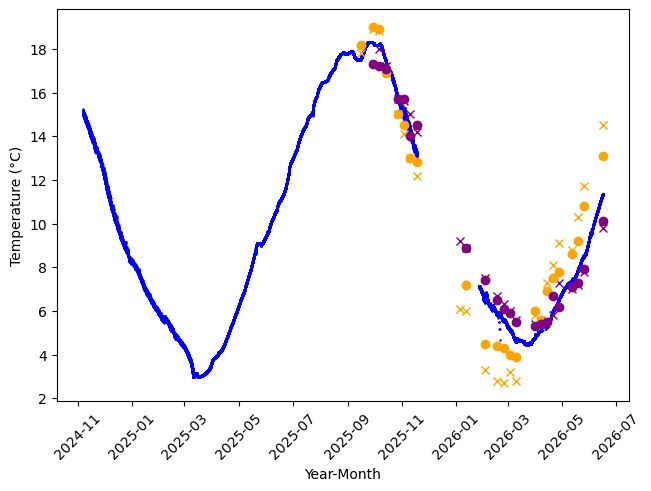

In [76]:
#creating the plot
mandf.columns = mandf.columns.str.strip() #This line was generated by Google Gemini to remove the leading and trailing whitespaces in the mandf dataframe.  


fig, ax = plt.subplots(layout='constrained')
#ax.plot(date1, filteredhobo, color="blue", label = "HOBO continuous temperature")
ax.scatter(date2, filteredhobo, color="blue", s = 0.5, label = "HOBO continuous temperature")
ax.plot(mandf.Date, mandf.loc[:,"Temp top before"], 'x', color = "orange", label = "manual temperature at top before pumping") #each variable in the manual field measurmemts data set is called by their column instead of naming each variable. The placeholders here are mandf.Date (which you should replace with the nameofdataframe.nameofcolumnfortime), mandf.loc[:,"Temp top before"] (which you should replace with nameofdataframe.loc[:, "Name of column for parameter"], and manual temperature at top before pumping (which you should replace with the name of the data for the legend). 
ax.plot(mandf.Date, mandf.loc[:,"Temp bottom before"], 'x', color = "purple", label = "manual temperature at bottom before pumping")
ax.plot(mandf.Date, mandf.loc[:,"Temp top after"], 'o', color = "orange", label = "manual temperature at top after pumping")
ax.plot(mandf.Date, mandf.loc[:,"Temp bottom after"], 'o', color = "purple", label = "manual temperature at bottom after pumping")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Temperature (°C)") #Temperature (°C) is a placeholder.
# plt.xlim((pd.to_datetime("2025-11-18 06"), pd.to_datetime("2025-11-18 16")))
# plt.ylim((6, 8))
# plt.xlim((pd.to_datetime("2026-01"), pd.to_datetime("2026-")))
# plt.ylim((6, 8))

# fig.legend(loc='outside upper right') #this line puts legend outside of graph, squishes it down, but is not awful. Run with # in front to see the graph at its default dimensions.

plt.show()

In [49]:
filteredhobo

1        15.17
2        15.23
3        15.19
4        15.13
5        15.19
         ...  
49621      NaN
49622      NaN
49623      NaN
49624      NaN
49625      NaN
Length: 49603, dtype: float32

In [32]:
filteredhobo
#row 36212 is the problem

1        15.17
2        15.23
3        15.19
4        15.13
5        15.19
         ...  
49621      NaN
49622      NaN
49623      NaN
49624      NaN
49625      NaN
Length: 49603, dtype: float32

KeyError: np.int32(1433)

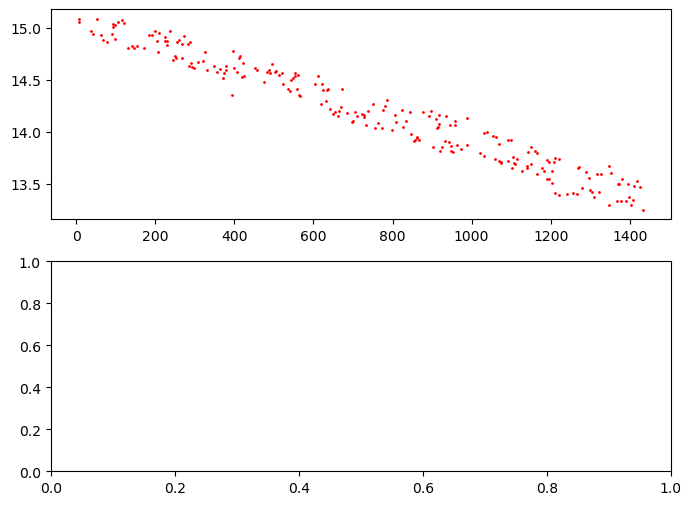

In [13]:
#need to make the temp and 
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
for i in hampelhobo.outlier_indices:
    axes[0].plot(i, hobodf["Temp"][i], 'ro', markersize=1)  # Mark as red


# Plot the filtered data in the second subplot
axes[1].plot(hobodf["Temp"], label='Filtered Data', color='g')


# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

In [14]:
df1 = pd.DataFrame(
    # [["a", "b"], ["c", "d"]],
    # index=["row 1", "row 2"],
    # columns=["col 1", "col 2"],
)
df1.to_excel("filteredhobo1.xlsx")